# MLflow Runs Analyzer (aggregated 3-row tables)

This notebook builds aggregated three-row tables (Baseline Neutral, Baseline Fair, FACTER Iteration 3) per model/dataset/predict_mode from MLflow runs.

## 1. Imports and setup

In [179]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Tuple
from datetime import datetime, timedelta
import warnings

warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

output_dir = Path("mlflow_analysis_output")
output_dir.mkdir(exist_ok=True)

## 2. Locate mlruns path

In [180]:
# Define the path to mlruns folder
mlruns_path = Path("facter-repr/mlruns")

if not mlruns_path.exists():
    # Try alternative path if the notebook is run from different directory
    mlruns_path = Path("./mlruns")
    
if not mlruns_path.exists():
    raise FileNotFoundError(f"mlruns folder not found at {mlruns_path}")

print(f"MLruns path: {mlruns_path.absolute()}")
print(f"Path exists: {mlruns_path.exists()}")

MLruns path: c:\Users\daimy\Uni\MasterAI\FACT\facter-repr\mlruns
Path exists: True


## 3. Load runs from mlflow.db

In [181]:
import sqlite3
import json

def load_runs_from_sqlite(mlruns_path: Path) -> List[Dict]:
    """Load runs from MLflow SQLite database."""
    db_path = mlruns_path.parent / "mlflow.db"
    
    if not db_path.exists():
        print(f"Warning: mlflow.db not found at {db_path}")
        return []
    
    runs = []
    try:
        conn = sqlite3.connect(str(db_path))
        cursor = conn.cursor()
        
        # Query the runs table
        cursor.execute("""
            SELECT run_uuid, status, start_time, end_time 
            FROM runs
        """)
        
        run_rows = cursor.fetchall()
        print(f"Found {len(run_rows)} runs in database")
        
        for run_uuid, status, start_time, end_time in run_rows:
            run_data = {
                'run_id': run_uuid,
                'status': status,
                'start_time': start_time,
                'end_time': end_time,
                'metrics': {},
                'params': {},
                'artifacts': []
            }
            
            # Query metrics for this run
            cursor.execute("""
                SELECT key, value FROM metrics WHERE run_uuid = ?
            """, (run_uuid,))
            
            for metric_key, metric_value in cursor.fetchall():
                try:
                    run_data['metrics'][metric_key] = float(metric_value)
                except (ValueError, TypeError):
                    run_data['metrics'][metric_key] = metric_value
            
            # Query parameters for this run
            cursor.execute("""
                SELECT key, value FROM params WHERE run_uuid = ?
            """, (run_uuid,))
            
            for param_key, param_value in cursor.fetchall():
                run_data['params'][param_key] = param_value
            
            runs.append(run_data)
        
        conn.close()
        return runs
        
    except Exception as e:
        print(f"Error reading database: {e}")
        return []

# Load all runs from database
print("Loading all runs from mlflow.db...")
all_runs = load_runs_from_sqlite(mlruns_path)
print(f"Total runs found: {len(all_runs)}")

Loading all runs from mlflow.db...
Found 48 runs in database
Total runs found: 48


## 4. Select FINISHED runs

In [182]:
# Filter runs from yesterday onward and keep FINISHED ones

yesterday = (datetime.now() - timedelta(days=2)).replace(hour=0, minute=0, second=0, microsecond=0)
recent_runs = []
for run in all_runs:
    ts = run.get('start_time')
    if ts is None:
        continue
    try:
        run_dt = datetime.fromtimestamp(int(ts) / 1000.0)
        if run_dt >= yesterday:
            recent_runs.append(run)
    except (ValueError, TypeError):
        continue

successful_runs = [r for r in recent_runs if r.get('status') == 'FINISHED']
failed_runs = [r for r in recent_runs if r.get('status') == 'FAILED']
unknown_runs = [r for r in recent_runs if r.get('status') not in ['FINISHED', 'FAILED']]

print(f"Date filter >= {yesterday:%Y-%m-%d %H:%M:%S}")
print(f"Runs after date filter: {len(recent_runs)} | FINISHED: {len(successful_runs)} | FAILED: {len(failed_runs)} | OTHER: {len(unknown_runs)}")

Date filter >= 2026-01-26 00:00:00
Runs after date filter: 35 | FINISHED: 22 | FAILED: 8 | OTHER: 5


## 5. Build metrics_df

In [183]:
# Extract metrics from successful runs (dropping metrics that start with "stage")
metrics_data = []
for run in successful_runs:
    row = {'run_id': run['run_id']}
    row.update({k: v for k, v in run.get('metrics', {}).items() if not str(k).startswith('stage')})
    metrics_data.append(row)

metrics_df = pd.DataFrame(metrics_data)
print(f"metrics_df shape: {metrics_df.shape}")

metrics_df shape: (22, 136)


In [184]:
metrics_df

,run_id,data.cal_n,data.test_n,data.items_n,catalog.items_n,item_embedder.items_n,repair.keying.is_tuple,protected_cols_count,offline.q_alpha0,offline.S_mean,...,iter3.SNSV.gender,iter3.SNSR.age,iter3.SNSV.age,iter3.SNSR.occupation,iter3.SNSV.occupation,iter3.ValidAtK.mean,CFR_all,CFR_gender,CFR_age,CFR_occupation
0,d99acb5a53ac4b7d8f6b65a363efe68a,2625.0,1125.0,181839.0,177780.0,181839.0,0.0,3.0,1.028944,0.919360,...,0.015832,0.024037,0.014804,0.077415,0.039841,0.887733,0.921865,0.911861,0.925328,0.922591
1,49351a18cab1452b9c8b87aab848722a,2625.0,1125.0,181839.0,177780.0,181839.0,0.0,3.0,1.026632,0.816926,...,0.004018,0.014406,0.011743,0.047998,0.034396,NaN,0.700411,0.694620,0.695814,0.689753
2,aa1e6269f20c4d42a0bbaddb2e76241f,1750.0,750.0,3883.0,3883.0,3883.0,0.0,3.0,1.003558,0.847280,...,0.017413,0.072624,0.031301,0.088471,0.028812,0.743200,0.710754,0.705208,0.696699,0.673633
3,d726508ee7634c9aab0a1dd8e281167e,1750.0,750.0,3883.0,3883.0,3883.0,0.0,3.0,1.005017,0.850350,...,0.023217,0.064428,0.027776,0.055874,0.022296,0.630000,0.692861,0.696141,0.696942,0.703777
4,2537dbbc7b6d4a7dbb37bea8be2a47b2,1750.0,750.0,3883.0,3883.0,3883.0,0.0,3.0,0.990895,0.754921,...,0.004116,0.025570,0.012537,0.024362,0.012233,NaN,0.561677,0.261828,0.468585,0.520670
5,1e971b98c37f4222ac8803c8a21a969b,1750.0,750.0,3883.0,3883.0,3883.0,0.0,3.0,1.016186,0.795458,...,0.002541,0.011315,0.007434,0.019870,0.010379,NaN,0.526700,0.231383,0.438699,0.496892
6,8049ff67063b4f8cba3aa80872550a04,1750.0,750.0,3883.0,3883.0,3883.0,0.0,3.0,1.024178,0.877717,...,0.036957,0.118014,0.045178,0.131369,0.056898,0.596000,0.750971,0.639034,0.620877,0.702991
7,2f55d224c6884ae4864829898f671f0d,1750.0,750.0,3883.0,3883.0,3883.0,0.0,3.0,0.995894,0.753406,...,0.003219,0.018610,0.009422,0.024351,0.012228,NaN,0.333636,0.154927,0.273049,0.291060
8,3d8dadba06444929bc360f365afe0c96,1750.0,750.0,3883.0,3883.0,3883.0,0.0,3.0,1.007573,0.852080,...,0.016770,0.110994,0.040909,0.059964,0.025603,0.709067,0.702935,0.699974,0.694901,0.711312
9,d6b5d12327d04ad299299ba33af95a57,2625.0,1125.0,181839.0,177780.0,181839.0,0.0,3.0,1.026161,0.919407,...,0.012182,0.018954,0.014370,0.081655,0.039548,0.890400,0.920342,0.895038,0.907534,0.920750


In [185]:
display(metrics_df[['iter1.violations.fixedQ0','iter2.violations.fixedQ0','iter3.violations.fixedQ0']])
display(metrics_df[['iter1.violations.fixedQ0.corrected','iter2.violations.fixedQ0.corrected','iter3.violations.fixedQ0.corrected']])
display(metrics_df[['iter1.violations.fixedQstar','iter2.violations.fixedQstar','iter3.violations.fixedQstar']])
display(metrics_df[['iter1.violations', 'iter2.violations', 'iter3.violations']])

,iter1.violations.fixedQ0,iter2.violations.fixedQ0,iter3.violations.fixedQ0
0,95.0,106.0,106.0
1,102.0,99.0,101.0
2,57.0,58.0,60.0
3,62.0,65.0,81.0
4,68.0,74.0,75.0
5,70.0,86.0,76.0
6,49.0,54.0,51.0
7,60.0,64.0,66.0
8,51.0,56.0,46.0
9,115.0,130.0,125.0


,iter1.violations.fixedQ0.corrected,iter2.violations.fixedQ0.corrected,iter3.violations.fixedQ0.corrected
0,87.0,97.0,98.0
1,99.0,91.0,92.0
2,50.0,40.0,40.0
3,51.0,46.0,64.0
4,61.0,60.0,57.0
5,60.0,70.0,62.0
6,44.0,29.0,35.0
7,52.0,42.0,48.0
8,43.0,37.0,28.0
9,107.0,122.0,118.0


,iter1.violations.fixedQstar,iter2.violations.fixedQstar,iter3.violations.fixedQstar
0,2.0,4.0,2.0
1,1.0,1.0,1.0
2,8.0,9.0,9.0
3,5.0,6.0,8.0
4,9.0,8.0,6.0
5,7.0,7.0,8.0
6,6.0,8.0,7.0
7,6.0,6.0,7.0
8,10.0,7.0,8.0
9,1.0,2.0,2.0


,iter1.violations,iter2.violations,iter3.violations
0,25.0,6.0,2.0
1,31.0,6.0,1.0
2,16.0,11.0,9.0
3,13.0,9.0,9.0
4,17.0,11.0,6.0
5,17.0,9.0,8.0
6,13.0,11.0,8.0
7,17.0,9.0,7.0
8,14.0,9.0,9.0
9,32.0,7.0,2.0


## 6. Build params_df

In [186]:
# Extract parameters from successful runs
params_data = []
for run in successful_runs:
    row = {'run_id': run['run_id']}
    row.update(run.get('params', {}))
    params_data.append(row)

params_df = pd.DataFrame(params_data)
print(f"params_df shape: {params_df.shape}")

params_df shape: (22, 28)


## 7. Build long_df and helpers

In [187]:
# Helpers and long-format build for final aggregates

metrics_of_interest = ['ndcg_multi', 'ndcg_single', 'recall_multi', 'recall_single', 'SNSV', 'CFR', 'n_violations']

# Helper: find metric columns containing all terms (case-insensitive, skip *_mean/_std aggregates)
def find_metric_cols(index_like_iterable, include_terms):
    cols = []
    for c in index_like_iterable:
        lc = str(c).lower()
        if all(term in lc for term in include_terms):
            cols.append(c)
    cols = [c for c in cols if not (str(c).endswith('_std') or str(c).endswith('_mean'))]
    return cols

# Helper: pick metric with optional iteration preference
def pick_metric(row_s, include_terms, prefer_iter=None):
    candidates = find_metric_cols(row_s.index, include_terms)
    if prefer_iter is not None:
        with_pref = [c for c in candidates if f"iter{prefer_iter}" in str(c).lower()]
        if with_pref:
            candidates = with_pref
    if not candidates:
        return np.nan
    candidates = sorted(candidates, key=lambda x: (('@' in str(x)) is False, len(str(x))))
    return row_s[candidates[0]]

# Helper: pick baseline-prefixed metric
# baseline_prefix examples: 'baseline_neutral', 'baseline_fair'
def pick_baseline(row_s, baseline_prefix, include_terms):
    prefix = baseline_prefix.lower() + '.'
    candidates = [c for c in row_s.index if str(c).lower().startswith(prefix)
                  and all(t in str(c).lower() for t in include_terms)]
    candidates = [c for c in candidates if not (str(c).endswith('_std') or str(c).endswith('_mean'))]
    if not candidates:
        return np.nan
    candidates = sorted(candidates, key=lambda x: len(str(x)))
    return row_s[candidates[0]]

# Build long_df once from metrics_df + params_df
if 'metrics_df' not in globals() or 'params_df' not in globals():
    print("metrics_df/params_df not available; run earlier cells.")
else:
    merged_runs = metrics_df.merge(params_df, on='run_id', how='left', suffixes=('', '_param'))
    records = []
    for _, row in merged_runs.iterrows():
        model_id = row.get('model_id', 'Unknown')
        dataset = row.get('dataset', 'Unknown')
        predict_mode = row.get('predict_mode', 'Unknown')
        seed = row.get('seed')
        run_id = row.get('run_id')

        # Baseline neutral
        neutral = {'variant': 'Baseline Neutral', 'model_id': model_id, 'dataset': dataset, 'predict_mode': predict_mode, 'seed': seed, 'run_id': run_id}
        neutral.update({
            'ndcg_multi': pick_baseline(row, 'baseline_neutral', ['ndcg', 'multi']),
            'ndcg_single': pick_baseline(row, 'baseline_neutral', ['ndcg', 'single']),
            'recall_multi': pick_baseline(row, 'baseline_neutral', ['recall', 'multi']),
            'recall_single': pick_baseline(row, 'baseline_neutral', ['recall', 'single']),
            'SNSV': pick_baseline(row, 'baseline_neutral', ['snsv']),
            'SNSV_gender': pick_baseline(row, 'baseline_neutral', ['snsv', 'gender']),
            'SNSV_occupation': pick_baseline(row, 'baseline_neutral', ['snsv', 'occupation']),
            'SNSV_age': pick_baseline(row, 'baseline_neutral', ['snsv', 'age']),
            'CFR': pick_baseline(row, 'baseline_neutral', ['cfr', 'all']),
            'CFR_gender': pick_baseline(row, 'baseline_neutral', ['cfr', 'gender']),
            'CFR_occupation': pick_baseline(row, 'baseline_neutral', ['cfr', 'occupation']),
            'CFR_age': pick_baseline(row, 'baseline_neutral', ['cfr', 'age'])
        })
        if pd.isna(neutral['CFR']):
            neutral['CFR'] = pick_baseline(row, 'baseline_neutral', ['cfr'])
        neutral['n_violations'] = pick_baseline(row, 'baseline_neutral', ['n_violations'])
        records.append(neutral)

        # Baseline fair
        fair = {'variant': 'Baseline Fair', 'model_id': model_id, 'dataset': dataset, 'predict_mode': predict_mode, 'seed': seed, 'run_id': run_id}
        fair.update({
            'ndcg_multi': pick_baseline(row, 'baseline_fair', ['ndcg', 'multi']),
            'ndcg_single': pick_baseline(row, 'baseline_fair', ['ndcg', 'single']),
            'recall_multi': pick_baseline(row, 'baseline_fair', ['recall', 'multi']),
            'recall_single': pick_baseline(row, 'baseline_fair', ['recall', 'single']),
            'SNSV': pick_baseline(row, 'baseline_fair', ['snsv']),
            'SNSV_gender': pick_baseline(row, 'baseline_fair', ['snsv', 'gender']),
            'SNSV_occupation': pick_baseline(row, 'baseline_fair', ['snsv', 'occupation']),
            'SNSV_age': pick_baseline(row, 'baseline_fair', ['snsv', 'age']),
            'CFR': pick_baseline(row, 'baseline_fair', ['cfr', 'all']),
            'CFR_gender': pick_baseline(row, 'baseline_fair', ['cfr', 'gender']),
            'CFR_occupation': pick_baseline(row, 'baseline_fair', ['cfr', 'occupation']),
            'CFR_age': pick_baseline(row, 'baseline_fair', ['cfr', 'age'])
        })
        if pd.isna(fair['CFR']):
            fair['CFR'] = pick_baseline(row, 'baseline_fair', ['cfr'])
        fair['n_violations'] = pick_baseline(row, 'baseline_fair', ['n_violations'])
        records.append(fair)

        # FACTER (prefer iter3 then iter2/iter1/any)
        facter = {'variant': 'FACTOR Iteration 3', 'model_id': model_id, 'dataset': dataset, 'predict_mode': predict_mode, 'seed': seed, 'run_id': run_id}
        for key, terms in {
            'ndcg_multi': ['ndcg', 'multi'],
            'ndcg_single': ['ndcg', 'single'],
            'recall_multi': ['recall', 'multi'],
            'recall_single': ['recall', 'single'],
            'SNSV': ['snsv'],
            'SNSV_gender': ['snsv', 'gender'],
            'SNSV_occupation': ['snsv', 'occupation'],
            'SNSV_age': ['snsv', 'age'],
            'CFR': ['cfr'],
            'CFR_gender': ['cfr', 'gender'],
            'CFR_occupation': ['cfr', 'occupation'],
            'CFR_age': ['cfr', 'age'],
            'n_violations': ['violat']
        }.items():
            val = pick_metric(row, terms, prefer_iter=3)
            if pd.isna(val):
                val = pick_metric(row, terms, prefer_iter=2)
            if pd.isna(val):
                val = pick_metric(row, terms, prefer_iter=1)
            if pd.isna(val):
                val = pick_metric(row, terms, prefer_iter=None)
            facter[key] = val
        records.append(facter)

    long_df = pd.DataFrame(records)
    print(f"long_df built with {len(long_df)} rows")

long_df built with 66 rows


## 8. Per-combination 3-row tables

In [188]:
# Per-combination 3-row tables (mean ± std across seeds)

if 'long_df' not in globals() or long_df.empty:
    print("long_df not available; run the helper/aggregation cell first.")
else:
    # Include demographic-specific metrics
    metrics_of_interest = ['ndcg_multi', 'ndcg_single', 'recall_multi', 'recall_single', 
                          'SNSV', 'SNSV_gender', 'SNSV_occupation', 'SNSV_age',
                          'CFR', 'CFR_gender', 'CFR_occupation', 'CFR_age', 
                          'n_violations']
    
    group_cols = ['model_id', 'dataset', 'predict_mode']
    combo_tables = {}
    combined_rows = []
    _out_dir = output_dir if 'output_dir' in globals() else Path("mlflow_analysis_results")
    _out_dir.mkdir(exist_ok=True)

    combo_groups = list(long_df.groupby(group_cols))
    combo_groups.sort(key=lambda item: (
        0 if str(item[0][2]).lower() == 'open' else 1,
        item[0][0],
        item[0][1],
        item[0][2]
    ))

    for combo_key, combo_df in combo_groups:
        model_id, dataset, predict_mode = combo_key
        rows = []
        for variant_label in ['Baseline Neutral', 'Baseline Fair', 'FACTOR Iteration 3']:
            g = combo_df[combo_df['variant'] == variant_label]
            rec = {
                'row': variant_label,
                'model_id': model_id,
                'dataset': dataset,
                'predict_mode': predict_mode,
                'num_runs': len(g)
            }
            for m in metrics_of_interest:
                rec[f'{m}_mean'] = g[m].mean()
                rec[f'{m}_std'] = g[m].std()
            rows.append(rec)

        table_df = pd.DataFrame(rows)

        # Narrow display: row + num_runs + metric mean/std pairs (no rounding)
        display_cols = ['row', 'num_runs']
        for m in metrics_of_interest:
            display_cols.extend([f'{m}_mean', f'{m}_std'])
        display_df = table_df[display_cols].copy()

        combo_tables[combo_key] = table_df
        print(f"\n=== {model_id} | {dataset} | {predict_mode} ===")
        with pd.option_context('display.max_columns', None, 'display.expand_frame_repr', False):
            display(display_df)

        safe_name = f"{model_id}_{dataset}_{predict_mode}".replace(' ', '_').replace('|', '_').replace('/', '-')
        per_path = _out_dir / f"agg_3row_{safe_name}.csv"
        table_df.to_csv(per_path, index=False)

        combined_rows.append(table_df.copy())

    combined_df = pd.concat(combined_rows, ignore_index=True) if combined_rows else pd.DataFrame()
    combined_path = _out_dir / "agg_3row_all.csv"
    combined_df.to_csv(combined_path, index=False)
    print(f"\n✓ Exported per-combination 3-row tables and combined file: {combined_path}")


=== meta-llama/Llama-2-7b-chat-hf | ml-1m | open ===


,row,num_runs,ndcg_multi_mean,ndcg_multi_std,ndcg_single_mean,ndcg_single_std,recall_multi_mean,recall_multi_std,recall_single_mean,recall_single_std,SNSV_mean,SNSV_std,SNSV_gender_mean,SNSV_gender_std,SNSV_occupation_mean,SNSV_occupation_std,SNSV_age_mean,SNSV_age_std,CFR_mean,CFR_std,CFR_gender_mean,CFR_gender_std,CFR_occupation_mean,CFR_occupation_std,CFR_age_mean,CFR_age_std,n_violations_mean,n_violations_std
0,Baseline Neutral,3,0.028149,0.003238,0.015303,0.000224,0.025783,0.002963,0.029333,0.001333,0.016708,0.001982,0.007489,0.000681,0.019471,0.001531,0.023573,0.003094,0.640258,0.003575,0.624439,0.005020,0.651897,0.007146,0.627451,0.009768,45.333333,9.073772
1,Baseline Fair,3,0.025339,0.000592,0.013479,0.002624,0.021958,0.001560,0.023111,0.003079,0.020885,0.004384,0.009519,0.000575,0.021924,0.001307,0.030429,0.005848,0.727802,0.015805,0.682632,0.022051,0.708425,0.015453,0.688228,0.010433,55.000000,2.000000
2,FACTOR Iteration 3,3,0.022194,0.002258,0.011326,0.000820,0.019973,0.002144,0.023111,0.000770,0.023020,0.007964,0.017249,0.005557,0.021854,0.002040,0.025885,0.002175,0.711511,0.016304,0.712622,0.014420,0.701894,0.005286,0.699848,0.003893,8.333333,0.577350



=== meta-llama/Meta-Llama-3-8B-Instruct | amazon | open ===


,row,num_runs,ndcg_multi_mean,ndcg_multi_std,ndcg_single_mean,ndcg_single_std,recall_multi_mean,recall_multi_std,recall_single_mean,recall_single_std,SNSV_mean,SNSV_std,SNSV_gender_mean,SNSV_gender_std,SNSV_occupation_mean,SNSV_occupation_std,SNSV_age_mean,SNSV_age_std,CFR_mean,CFR_std,CFR_gender_mean,CFR_gender_std,CFR_occupation_mean,CFR_occupation_std,CFR_age_mean,CFR_age_std,n_violations_mean,n_violations_std
0,Baseline Neutral,2,0.004300,0.000647,0.002256,0.001510,0.004525,0.000719,0.004889,0.001886,0.0,0.0,0.021505,0.002502,0.042737,0.002340,0.016816,0.000636,0.889434,0.001433,0.870443,0.011207,0.863667,0.022966,0.865110,0.003633,107.5,2.121320
1,Baseline Fair,2,0.003569,0.000715,0.001414,0.000020,0.004257,0.000323,0.003556,0.000000,0.0,0.0,0.010418,0.000293,0.040589,0.002165,0.015613,0.001015,0.909359,0.031158,0.881542,0.003429,0.891514,0.005422,0.894245,0.013924,86.5,0.707107
2,FACTOR Iteration 3,2,0.003802,0.000194,0.001011,0.000422,0.003607,0.000147,0.002667,0.001257,0.0,0.0,0.014007,0.002581,0.039695,0.000207,0.014587,0.000307,0.921103,0.001077,0.903450,0.011896,0.921670,0.001302,0.916431,0.012582,2.0,0.000000



=== meta-llama/Meta-Llama-3-8B-Instruct | ml-1m | open ===


...


=== meta-llama/Meta-Llama-3-8B-Instruct | ml-1m | rank ===


,row,num_runs,ndcg_multi_mean,ndcg_multi_std,ndcg_single_mean,ndcg_single_std,recall_multi_mean,recall_multi_std,recall_single_mean,recall_single_std,SNSV_mean,SNSV_std,SNSV_gender_mean,SNSV_gender_std,SNSV_occupation_mean,SNSV_occupation_std,SNSV_age_mean,SNSV_age_std,CFR_mean,CFR_std,CFR_gender_mean,CFR_gender_std,CFR_occupation_mean,CFR_occupation_std,CFR_age_mean,CFR_age_std,n_violations_mean,n_violations_std
0,Baseline Neutral,3,0.465546,0.001676,0.224174,0.011454,0.432790,0.003960,0.442667,0.031184,0.025778,0.003456,0.003948,0.000255,0.014331,0.000814,0.018856,0.001804,0.532554,0.007476,0.268982,0.030294,0.497291,0.005240,0.444834,0.024006,61.333333,7.094599
1,Baseline Fair,3,0.456180,0.005566,0.227448,0.002796,0.426205,0.003856,0.447556,0.011951,0.023884,0.006371,0.004331,0.000102,0.012667,0.000820,0.016418,0.000496,0.534452,0.006333,0.255358,0.004375,0.490950,0.013659,0.450769,0.029163,55.666667,4.932883
2,FACTOR Iteration 3,3,0.437569,0.006580,0.220728,0.007823,0.406745,0.004978,0.429778,0.009828,0.024342,0.002806,0.004492,0.000693,0.012413,0.000253,0.013316,0.001957,0.552637,0.009575,0.282149,0.025121,0.525411,0.014258,0.463238,0.007021,7.666667,1.527525



=== mistralai/Mistral-7B-Instruct-v0.2 | ml-1m | rank ===


,row,num_runs,ndcg_multi_mean,ndcg_multi_std,ndcg_single_mean,ndcg_single_std,recall_multi_mean,recall_multi_std,recall_single_mean,recall_single_std,SNSV_mean,SNSV_std,SNSV_gender_mean,SNSV_gender_std,SNSV_occupation_mean,SNSV_occupation_std,SNSV_age_mean,SNSV_age_std,CFR_mean,CFR_std,CFR_gender_mean,CFR_gender_std,CFR_occupation_mean,CFR_occupation_std,CFR_age_mean,CFR_age_std,n_violations_mean,n_violations_std
0,Baseline Neutral,3,0.398886,0.004183,0.193218,0.003366,0.348587,0.002139,0.354667,0.001333,0.019555,0.000536,0.002777,0.000301,0.011809,0.000226,0.010695,0.000282,0.357726,0.004916,0.156546,0.013355,0.324968,0.022228,0.282989,0.015921,47.333333,3.511885
1,Baseline Fair,3,0.390633,0.005516,0.187630,0.000769,0.339835,0.003911,0.340000,0.007424,0.019060,0.001061,0.002942,0.000362,0.012035,0.000754,0.011241,0.000575,0.318290,0.031011,0.152347,0.011040,0.287952,0.007482,0.259171,0.032190,47.333333,6.658328
2,FACTOR Iteration 3,3,0.381223,0.001399,0.190672,0.004232,0.333768,0.001830,0.344000,0.004000,0.019230,0.000132,0.003333,0.000177,0.012160,0.000097,0.010180,0.000668,0.319848,0.014929,0.158611,0.018633,0.286986,0.015909,0.269566,0.004338,7.000000,0.000000



✓ Exported per-combination 3-row tables and combined file: mlflow_analysis_output\agg_3row_all.csv


## 9. Violations per iteration by model

Found data for 24 iteration-run combinations (ML1M, open-generation)
Models found: ['Llama-3' 'Llama-2' 'Mistral']
Runs per model: Model
Llama-2    3
Llama-3    2
Mistral    3
Name: run_id, dtype: int64

✓ Plot saved to: mlflow_analysis_output\violations_per_iteration_ml1m_open.png


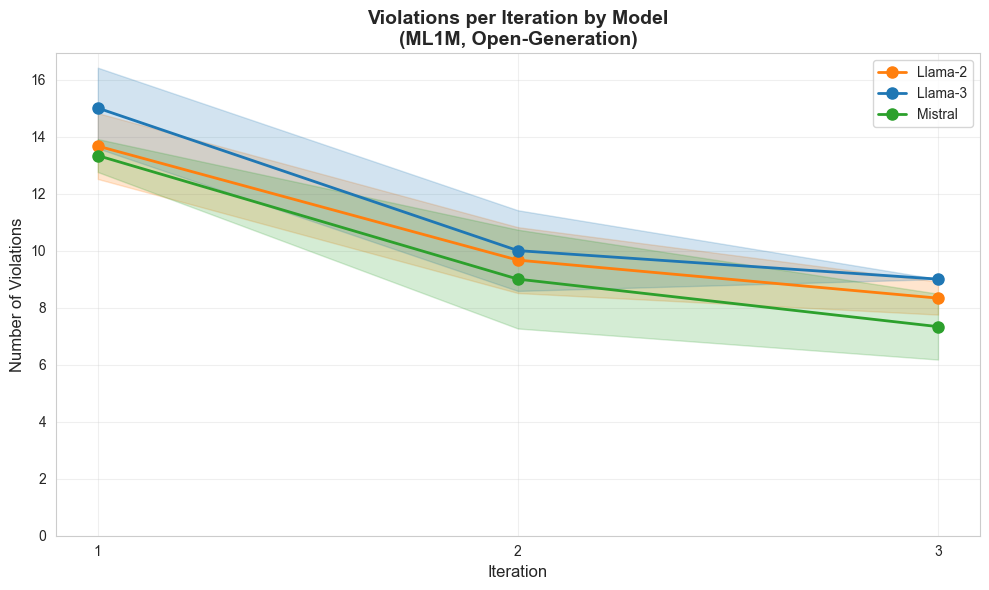


Violations summary (mean ± std):


,Model,Iteration,mean,std,count
0,Llama-2,1,13.666667,1.154701,3
1,Llama-2,2,9.666667,1.154701,3
2,Llama-2,3,8.333333,0.577350,3
3,Llama-3,1,15.000000,1.414214,2
4,Llama-3,2,10.000000,1.414214,2
5,Llama-3,3,9.000000,0.000000,2
6,Mistral,1,13.333333,0.577350,3
7,Mistral,2,9.000000,1.732051,3
8,Mistral,3,7.333333,1.154701,3


In [189]:
def plot_violations_per_iteration(violation_filters=None, title_suffix="", filename_suffix=""):
    """
    Plot violations per iteration for Llama3, Llama2, and Mistral models.
    
    Args:
        violation_filters: List of additional lowercase strings to filter violation columns.
                          If None or empty, matches any violation column.
        title_suffix: Additional text to add to the plot title (e.g., "for fixedQ0.corrected")
        filename_suffix: Additional text to add to the output filename
    """
    if 'metrics_df' not in globals() or 'params_df' not in globals():
        print("Run earlier cells first")
        return
    
    merged_runs = metrics_df.merge(params_df, on='run_id', how='left', suffixes=('', '_param'))
    
    plot_data = []
    for _, row in merged_runs.iterrows():
        # Filter by dataset and predict_mode
        dataset = str(row.get('dataset', '')).lower()
        predict_mode = str(row.get('predict_mode', '')).lower()
        
        if 'ml1m' not in dataset and 'ml-1m' not in dataset:
            continue
        if 'open' not in predict_mode:
            continue
        
        model_id = str(row.get('model_id', '')).lower()
        
        # More flexible model matching to handle various naming conventions
        matched_model = None
        if 'llama' in model_id and '3' in model_id:
            matched_model = 'Llama-3'
        elif 'llama' in model_id and '2' in model_id:
            matched_model = 'Llama-2'
        elif 'mistral' in model_id:
            matched_model = 'Mistral'
        
        if matched_model is None:
            continue
        
        # Extract violations for each iteration
        for iteration in [1, 2, 3]:
            # Build column filter criteria
            iter_cols = [c for c in row.index if f'iter{iteration}' in str(c).lower() and 'violat' in str(c).lower()]
            
            # Apply additional filters if provided
            if violation_filters:
                iter_cols = [c for c in iter_cols if all(f in str(c).lower() for f in violation_filters)]
            
            if not iter_cols:
                continue
            
            # Pick the first matching column
            iter_cols = sorted(iter_cols, key=lambda x: len(str(x)))
            violations = row[iter_cols[0]]
            
            if pd.notna(violations):
                plot_data.append({
                    'Model': matched_model,
                    'Iteration': iteration,
                    'Violations': violations,
                    'run_id': row.get('run_id')
                })
    
    if plot_data:
        plot_df = pd.DataFrame(plot_data)
        
        print(f"Found data for {len(plot_df)} iteration-run combinations (ML1M, open-generation{title_suffix})")
        print(f"Models found: {plot_df['Model'].unique()}")
        print(f"Runs per model: {plot_df.groupby('Model')['run_id'].nunique()}")
        
        # Calculate mean and std per model and iteration
        agg_plot = plot_df.groupby(['Model', 'Iteration'])['Violations'].agg(['mean', 'std', 'count']).reset_index()
        
        # Create the plot
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # Use actual models found in data
        colors = {'Llama-3': '#1f77b4', 'Llama-2': '#ff7f0e', 'Mistral': '#2ca02c'}
        for model in agg_plot['Model'].unique():
            model_data = agg_plot[agg_plot['Model'] == model]
            color = colors.get(model, None)
            ax.plot(model_data['Iteration'], model_data['mean'], marker='o', label=model, linewidth=2, markersize=8, color=color)
            ax.fill_between(
                model_data['Iteration'],
                model_data['mean'] - model_data['std'],
                model_data['mean'] + model_data['std'],
                alpha=0.2,
                color=color
            )
        
        ax.set_xlabel('Iteration', fontsize=12)
        ax.set_ylabel('Number of Violations', fontsize=12)
        title = f'Violations per Iteration{" " + title_suffix if title_suffix else ""} by Model\n(ML1M, Open-Generation)'
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_xticks([1, 2, 3])
        ax.set_ylim(bottom=0)
        
        plt.tight_layout()
        
        # Save the plot
        plot_path = output_dir / f"violations{filename_suffix}_per_iteration_ml1m_open.png"
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        print(f"\n✓ Plot saved to: {plot_path}")
        
        plt.show()
        
        # Display summary table
        print("\nViolations summary (mean ± std):")
        display(agg_plot)
    else:
        print(f"No violation data found for ML1M + open-generation{title_suffix}")

# Plot general violations
plot_violations_per_iteration(violation_filters=None, title_suffix="", filename_suffix="")

Found data for 24 iteration-run combinations (ML1M, open-generationfor fixedQ0.corrected)
Models found: ['Llama-3' 'Llama-2' 'Mistral']
Runs per model: Model
Llama-2    3
Llama-3    2
Mistral    3
Name: run_id, dtype: int64

✓ Plot saved to: mlflow_analysis_output\violations_fixedQ0_corrected_per_iteration_ml1m_open.png


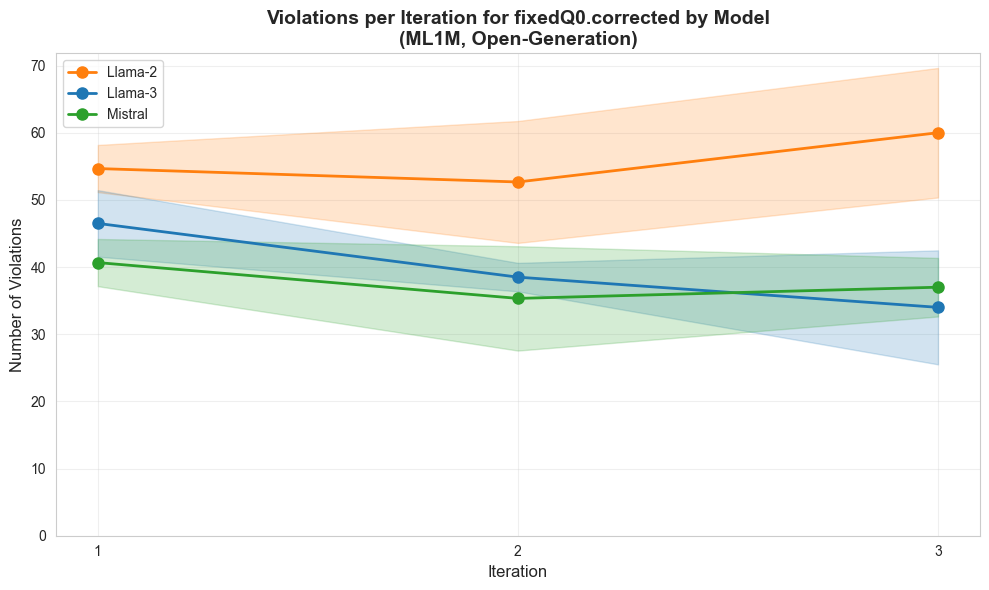


Violations summary (mean ± std):


,Model,Iteration,mean,std,count
0,Llama-2,1,54.666667,3.511885,3
1,Llama-2,2,52.666667,9.073772,3
2,Llama-2,3,60.000000,9.643651,3
3,Llama-3,1,46.500000,4.949747,2
4,Llama-3,2,38.500000,2.121320,2
5,Llama-3,3,34.000000,8.485281,2
6,Mistral,1,40.666667,3.511885,3
7,Mistral,2,35.333333,7.767453,3
8,Mistral,3,37.000000,4.358899,3


In [190]:
# Plot fixedQ0.corrected violations
plot_violations_per_iteration(
    violation_filters=['fixedq0', 'corrected'], 
    title_suffix="for fixedQ0.corrected", 
    filename_suffix="_fixedQ0_corrected"
)

Found data for 24 iteration-run combinations (ML1M, open-generationfor fixedQstar)
Models found: ['Llama-3' 'Llama-2' 'Mistral']
Runs per model: Model
Llama-2    3
Llama-3    2
Mistral    3
Name: run_id, dtype: int64

✓ Plot saved to: mlflow_analysis_output\violations_fixedQstar_per_iteration_ml1m_open.png


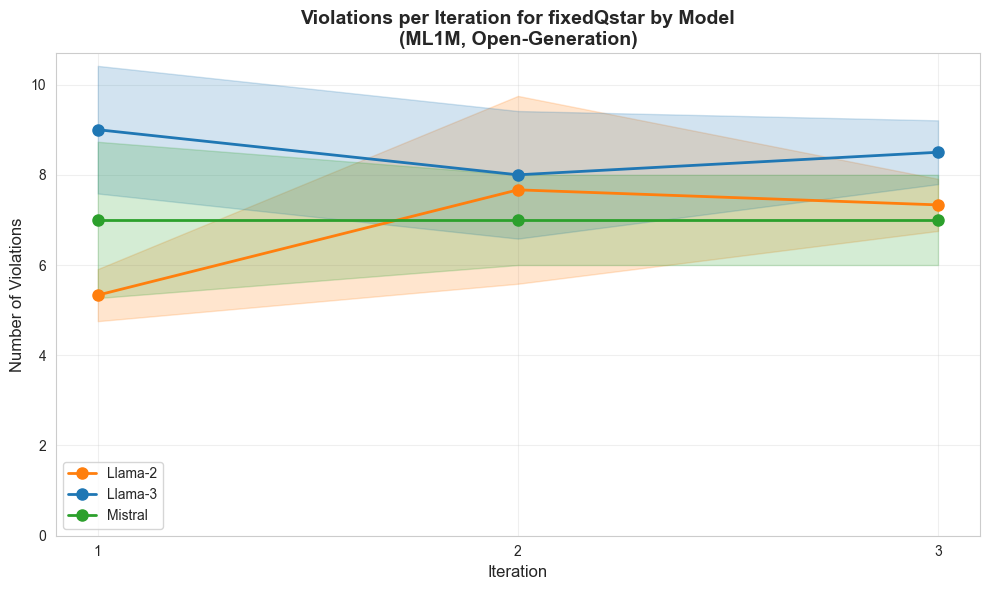


Violations summary (mean ± std):


,Model,Iteration,mean,std,count
0,Llama-2,1,5.333333,0.577350,3
1,Llama-2,2,7.666667,2.081666,3
2,Llama-2,3,7.333333,0.577350,3
3,Llama-3,1,9.000000,1.414214,2
4,Llama-3,2,8.000000,1.414214,2
5,Llama-3,3,8.500000,0.707107,2
6,Mistral,1,7.000000,1.732051,3
7,Mistral,2,7.000000,1.000000,3
8,Mistral,3,7.000000,1.000000,3


In [191]:
# Plot fixedQstar violations
plot_violations_per_iteration(
    violation_filters=['fixedqstar'], 
    title_suffix="for fixedQstar", 
    filename_suffix="_fixedQstar"
)